In [13]:
import os, json, glob
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from collections import defaultdict
from rliable import library as rly
from rliable import metrics as rly_metrics
from rliable import plot_utils as rly_plot

matplotlib.rcParams.update({
    "figure.figsize": (10, 6), "font.size": 12,
    "axes.labelsize": 14, "axes.titlesize": 14,
    "legend.fontsize": 10, "xtick.labelsize": 11,
    "ytick.labelsize": 11, "figure.dpi": 150,
    "savefig.bbox": "tight", "savefig.dpi": 200,
})

In [14]:
RESULTS_DIR = "./results"
FIGURES_DIR = "./figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

data = defaultdict(lambda: defaultdict(dict))
for d in sorted(Path(RESULTS_DIR).iterdir()):
    if not d.is_dir() or d.name.startswith("."):
        continue
    cfg_p, met_p, sum_p = d / "config.json", d / "metrics.npz", d / "summary.json"
    if not all(p.exists() for p in [cfg_p, met_p, sum_p]):
        continue
    cfg = json.loads(cfg_p.read_text())
    met = dict(np.load(met_p, allow_pickle=True))
    summ = json.loads(sum_p.read_text())
    data[cfg["method"]][cfg["env_id"]][cfg["seed"]] = dict(
        config=cfg, returns=met["episode_returns"],
        lengths=met["episode_lengths"], steps=met["episode_steps"],
        intrinsic=met.get("intrinsic_rewards", np.array([])),
        summary=summ,
    )

methods = sorted(data.keys())
env_ids = sorted({e for m in data.values() for e in m})
print(f"Methods: {methods}")
print(f"Environments: {len(env_ids)}")
for m in methods:
    n = sum(len(v) for v in data[m].values())
    print(f"  {m:20s}  {n} runs / {len(data[m])} envs")

Methods: ['e3b', 'icm', 'noveld', 'ppo_baseline', 'pseudocounts', 'ride_none', 'rnd', 'rnd_raw_dvh', 'simhash_none']
Environments: 14
  e3b                   42 runs / 14 envs
  icm                   44 runs / 14 envs
  noveld                42 runs / 14 envs
  ppo_baseline          48 runs / 14 envs
  pseudocounts          42 runs / 14 envs
  ride_none             26 runs / 14 envs
  rnd                   48 runs / 14 envs
  rnd_raw_dvh           26 runs / 14 envs
  simhash_none          26 runs / 14 envs


In [15]:
short_names = {e: e.replace("MiniGrid-", "").replace("CustomMiniGrid-", "C:") for e in env_ids}
rows = [{"Method": m, **{short_names[e]: len(data[m].get(e, {})) for e in env_ids}} for m in methods]
df = pd.DataFrame(rows).set_index("Method")
print("Seeds per method x environment:")
print(df.to_string())
total = sum(len(data[m][e]) for m in methods for e in data[m])
print(f"\nTotal runs: {total}  |  Methods: {len(methods)}  |  Envs: {len(env_ids)}")

Seeds per method x environment:
              CustomBranchingCorridors-v0  CustomBranchingCorridorsFixed-v0  CustomDelayedKeySpawn-v0  CustomFourRoomsTimed-v0  CustomKeyChain-v0  CustomNoisyTVEmptyRoom-v0  CustomTreasureIsland-v0  DoorKey-8x8-v0  Empty-8x8-v0  FourRooms-v0  KeyCorridorS6R3-v0  LavaGapS7-v0  MultiRoom-N4-S5-v0  ObstructedMaze-2Dlhb-v0
Method                                                                                                                                                                                                                                                                                                                          
e3b                                     3                                 3                         2                        3                  3                          2                        2               5             5             5                   1             2                   5                        1
icm  

In [16]:
COLORS = {
    "ppo_baseline": "#808080", "rnd": "#1f77b4", "icm": "#ff7f0e",
    "pseudocounts": "#2ca02c", "e3b": "#d62728", "noveld": "#9467bd",
    "ride_none": "#17becf", "simhash_none": "#bcbd22", "rnd_raw_dvh": "#e377c2",
}
LABELS = {
    "ppo_baseline": "PPO", "rnd": "RND", "icm": "ICM",
    "pseudocounts": "Pseudo.", "e3b": "E3B", "noveld": "NovelD",
    "ride_none": "RIDE", "simhash_none": "SimHash", "rnd_raw_dvh": "RND-DVH",
}
ENV_SHORT = {
    "MiniGrid-DoorKey-8x8-v0": "DoorKey-8x8",
    "MiniGrid-FourRooms-v0": "FourRooms",
    "MiniGrid-MultiRoom-N4-S5-v0": "MultiRoom-N4-S5",
    "CustomMiniGrid-NoisyTVEmptyRoom-v0": "NoisyTV-EmptyRoom",
    "CustomMiniGrid-BranchingCorridors-v0": "BranchingCorridors",
    "CustomMiniGrid-KeyChain-v0": "KeyChain",
    "MiniGrid-Empty-8x8-v0": "Empty-8x8",
    "CustomMiniGrid-BranchingCorridorsFixed-v0": "BranchCorr-Fixed",
    "CustomMiniGrid-DelayedKeySpawn-v0": "DelayedKeySpawn",
    "CustomMiniGrid-FourRoomsTimed-v0": "FourRoomsTimed",
    "CustomMiniGrid-TreasureIsland-v0": "TreasureIsland",
    "MiniGrid-KeyCorridorS6R3-v0": "KeyCorridor-S6R3",
    "MiniGrid-LavaGapS7-v0": "LavaGap-S7",
    "MiniGrid-ObstructedMaze-2Dlhb-v0": "ObstrMaze-2Dlhb",
}
PROCGEN_ENVS = [
    "MiniGrid-Empty-8x8-v0", "MiniGrid-LavaGapS7-v0", "MiniGrid-DoorKey-8x8-v0",
    "MiniGrid-FourRooms-v0", "MiniGrid-MultiRoom-N4-S5-v0",
    "CustomMiniGrid-BranchingCorridors-v0", "CustomMiniGrid-FourRoomsTimed-v0",
    "CustomMiniGrid-NoisyTVEmptyRoom-v0",
]
FIXED_ENVS = [
    "CustomMiniGrid-BranchingCorridorsFixed-v0", "CustomMiniGrid-KeyChain-v0",
    "CustomMiniGrid-DelayedKeySpawn-v0", "CustomMiniGrid-TreasureIsland-v0",
    "MiniGrid-KeyCorridorS6R3-v0", "MiniGrid-ObstructedMaze-2Dlhb-v0",
]

def _c(m): return COLORS.get(m, "black")
def _l(m): return LABELS.get(m, m)
def _short(e): return ENV_SHORT.get(e, short_names.get(e, e))

def smooth(x, w=100):
    if len(x) < w: return x
    k = np.ones(w) / w
    return np.convolve(np.concatenate([np.full(w-1, x[0]), x]), k, mode="valid")

def aw(n): return max(5, min(50, n // 20))
def sfmt(x, _): return f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}k"

In [17]:
# Score matrices for rliable (exclude envs with <2 seeds for any method)
MIN_SEEDS = 2
rliable_envs = [e for e in env_ids
    if all(len(data[m].get(e, {})) >= MIN_SEEDS for m in methods)]
print(f"rliable: {len(rliable_envs)}/{len(env_ids)} envs qualify")

raw_by_env, norm_by_env = {}, {}
for env in rliable_envs:
    raw_by_env[env] = {m: [data[m][env][s]["summary"]["final_return_100"]
                           for s in sorted(data[m][env])]
                       for m in methods if env in data[m]}
    vals = [v for m in raw_by_env[env] for v in raw_by_env[env][m]]
    lo, hi = min(vals), max(vals)
    rng = hi - lo if hi > lo else 1.0
    norm_by_env[env] = {m: [(v-lo)/rng for v in raw_by_env[env][m]] for m in raw_by_env[env]}

score_dict = {}
for m in methods:
    m_envs = [e for e in rliable_envs if m in norm_by_env.get(e, {})]
    if not m_envs: continue
    ns = min(len(norm_by_env[e][m]) for e in m_envs)
    score_dict[_l(m)] = np.array([[norm_by_env[e][m][s] for e in rliable_envs] for s in range(ns)])

for m, s in score_dict.items():
    print(f"  {m:12s}  seeds={s.shape[0]}  mean={s.mean():.4f}")

rliable: 12/14 envs qualify
  E3B           seeds=2  mean=0.5555
  ICM           seeds=2  mean=0.8453
  NovelD        seeds=2  mean=0.8757
  PPO           seeds=3  mean=0.7532
  Pseudo.       seeds=2  mean=0.2476
  RIDE          seeds=2  mean=0.4268
  RND           seeds=3  mean=0.0552
  RND-DVH       seeds=2  mean=0.7276
  SimHash       seeds=2  mean=0.6347


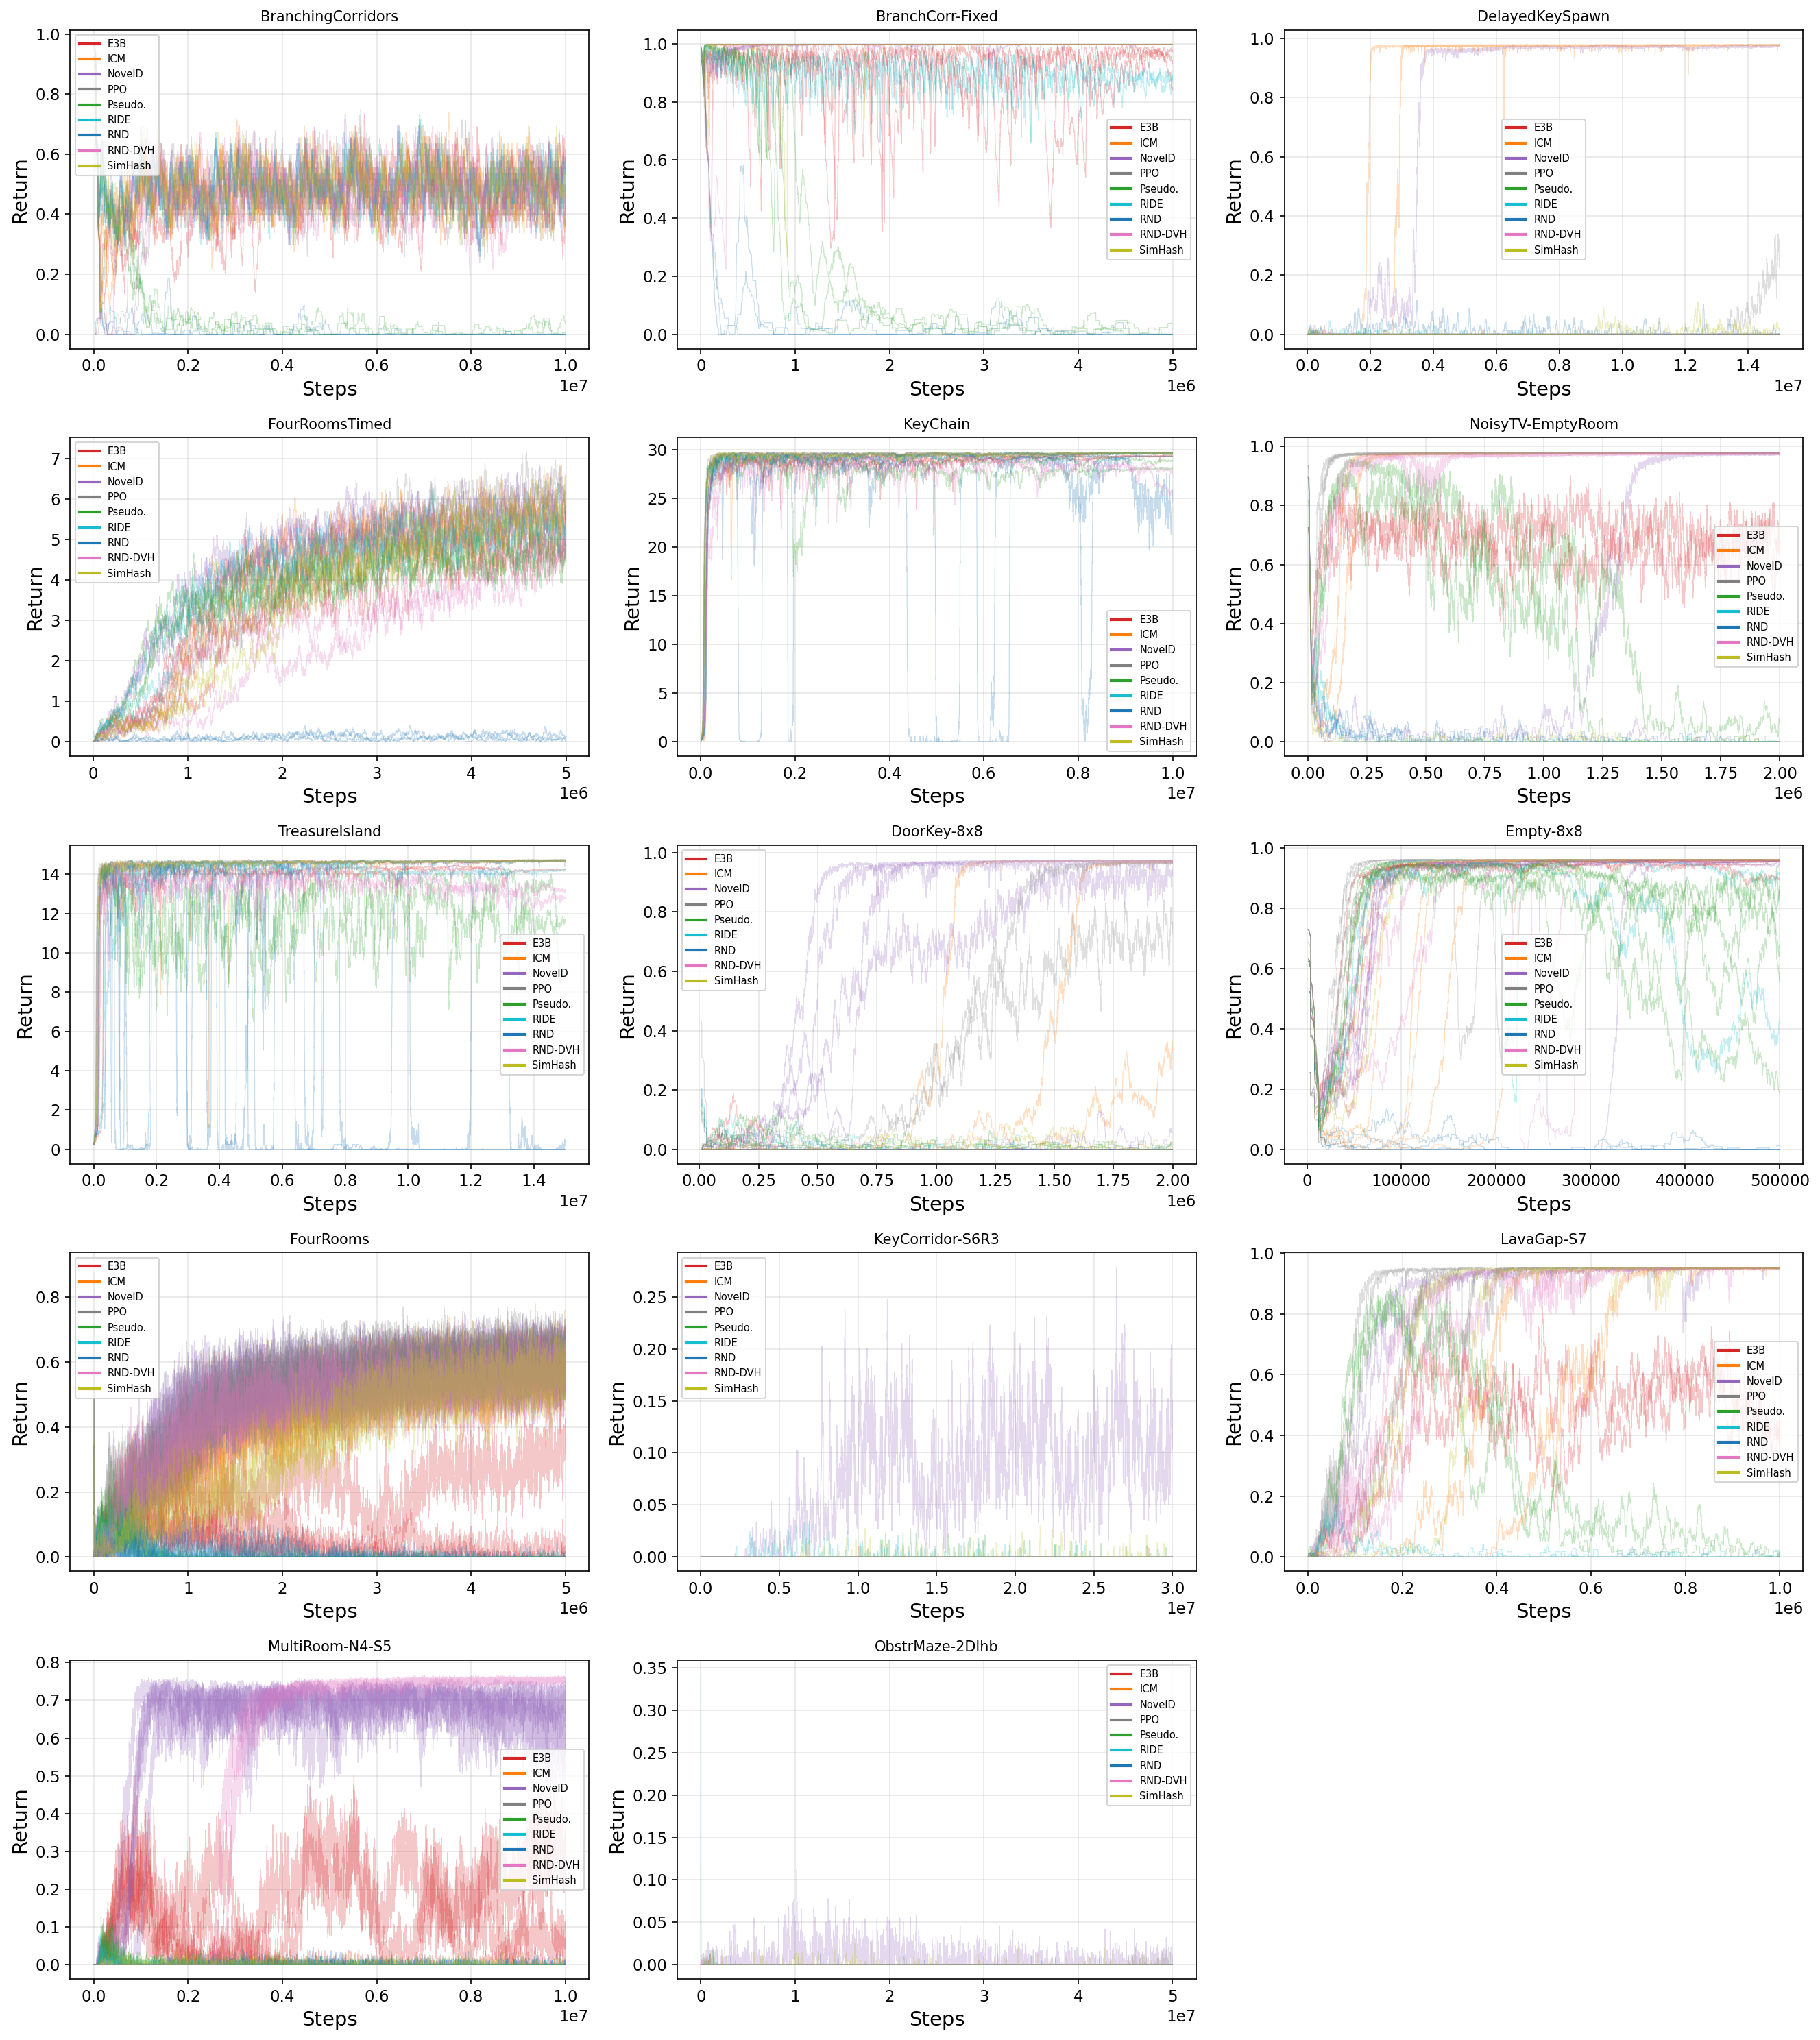

In [18]:
ncols = min(3, len(env_ids))
nrows = -(-len(env_ids) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), squeeze=False)

for idx, eid in enumerate(env_ids):
    ax = axes[idx // ncols][idx % ncols]
    ax.set_title(_short(eid), fontsize=10)
    ax.set_xlabel("Steps"); ax.set_ylabel("Return")
    for m in methods:
        if eid not in data[m]: continue
        for seed, d in data[m][eid].items():
            y = smooth(d["returns"], w=50)
            x = d["steps"][:len(y)] if len(d["steps"]) >= len(y) else np.arange(len(y))
            ax.plot(x, y, color=_c(m), alpha=0.25, linewidth=0.6)
        ax.plot([], [], color=_c(m), label=_l(m), linewidth=2)
    ax.legend(fontsize=7, loc="best"); ax.grid(True, alpha=0.3)

for idx in range(len(env_ids), nrows*ncols):
    axes[idx//ncols][idx%ncols].set_visible(False)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/learning_curves.png")
plt.show()

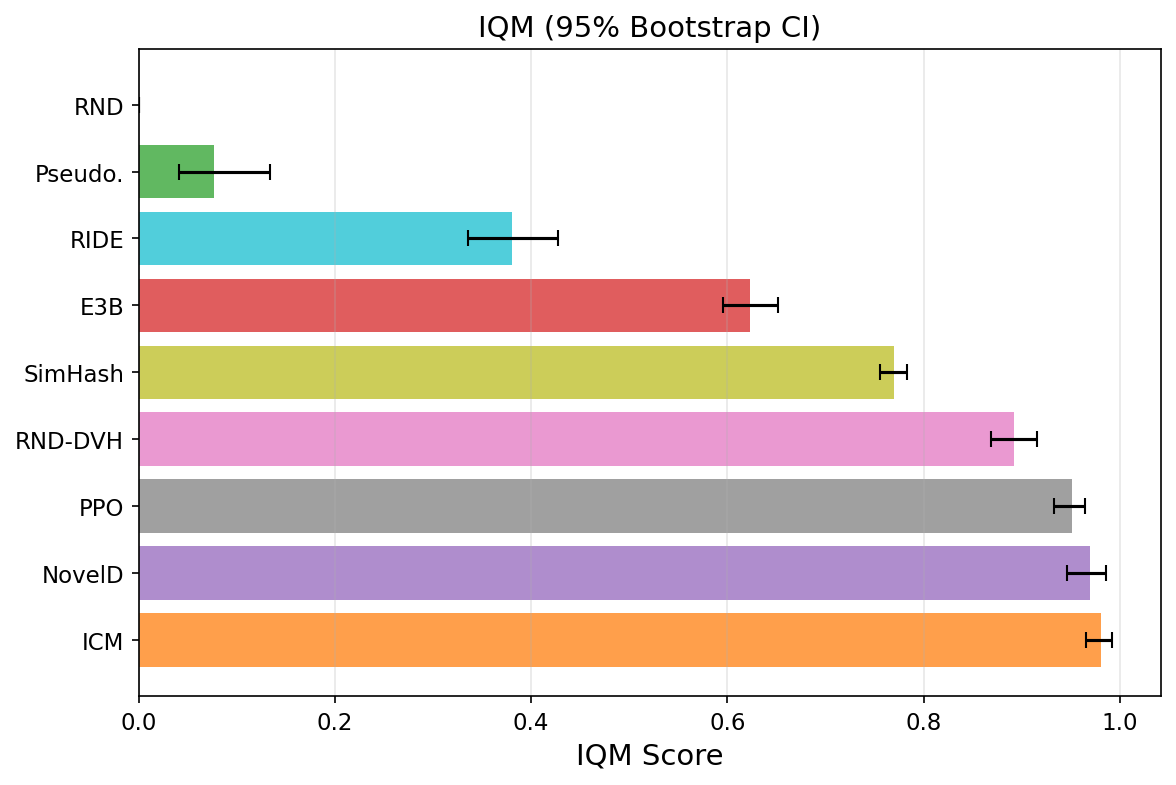

In [19]:
iqm_fn = lambda x: np.array([rly_metrics.aggregate_iqm(x)])
iqm_scores, iqm_cis = rly.get_interval_estimates(score_dict, iqm_fn, reps=50_000)

algs = sorted(score_dict, key=lambda m: iqm_scores[m][0], reverse=True)
vals = [iqm_scores[m][0] for m in algs]
lo = [iqm_cis[m][0][0] for m in algs]
hi = [iqm_cis[m][1][0] for m in algs]
label_to_key = {v: k for k, v in LABELS.items()}

fig, ax = plt.subplots(figsize=(8, max(3, 0.6*len(algs))))
y = np.arange(len(algs))
ax.barh(y, vals,
    xerr=[[v-l for v,l in zip(vals,lo)], [h-v for v,h in zip(vals,hi)]],
    color=[_c(label_to_key.get(m, m)) for m in algs], alpha=0.75, capsize=4)
ax.set_yticks(y); ax.set_yticklabels(algs)
ax.set_xlabel("IQM Score"); ax.set_title("IQM (95% Bootstrap CI)")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout(); plt.savefig(f"{FIGURES_DIR}/iqm_comparison.png"); plt.show()

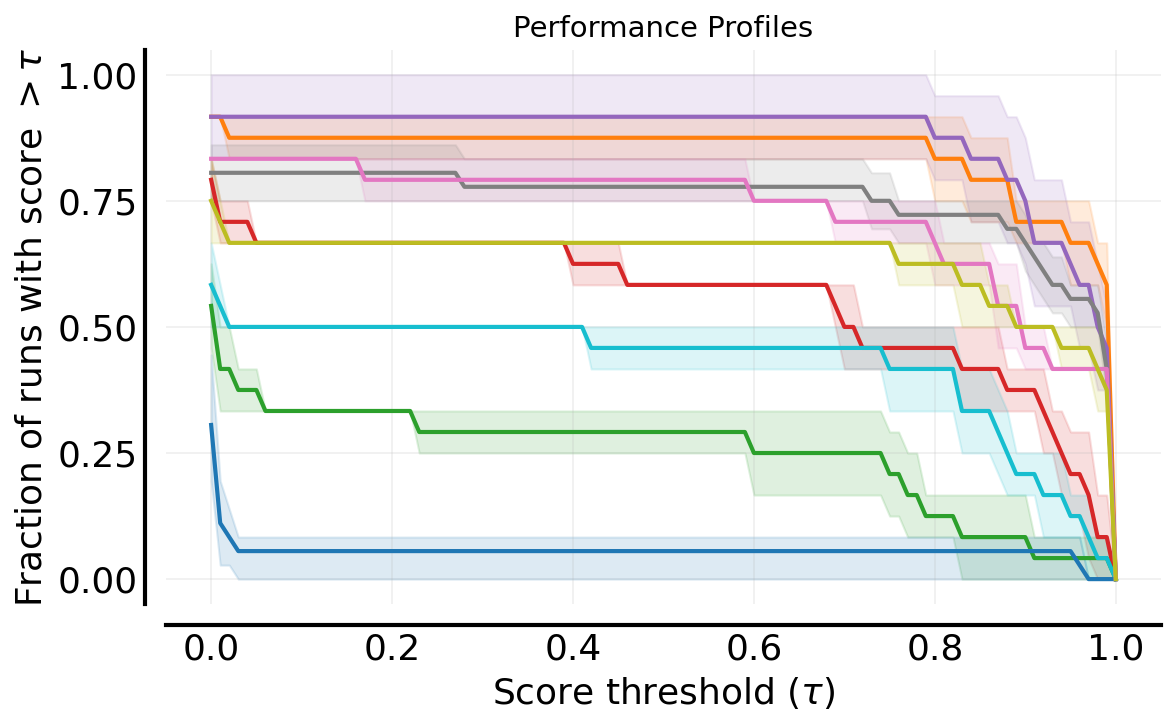

In [20]:
tau_list = np.linspace(0, 1, 101)
perf_profiles, perf_cis = rly.create_performance_profile(score_dict, tau_list, reps=50_000)
colors_map = {_l(m): _c(m) for m in methods}

fig, ax = plt.subplots(figsize=(8, 5))
rly_plot.plot_performance_profiles(perf_profiles, tau_list=tau_list,
    performance_profile_cis=perf_cis, colors=colors_map,
    xlabel=r"Score threshold ($\tau$)", ax=ax)
ax.set_title("Performance Profiles")
plt.tight_layout(); plt.savefig(f"{FIGURES_DIR}/performance_profiles.png"); plt.show()

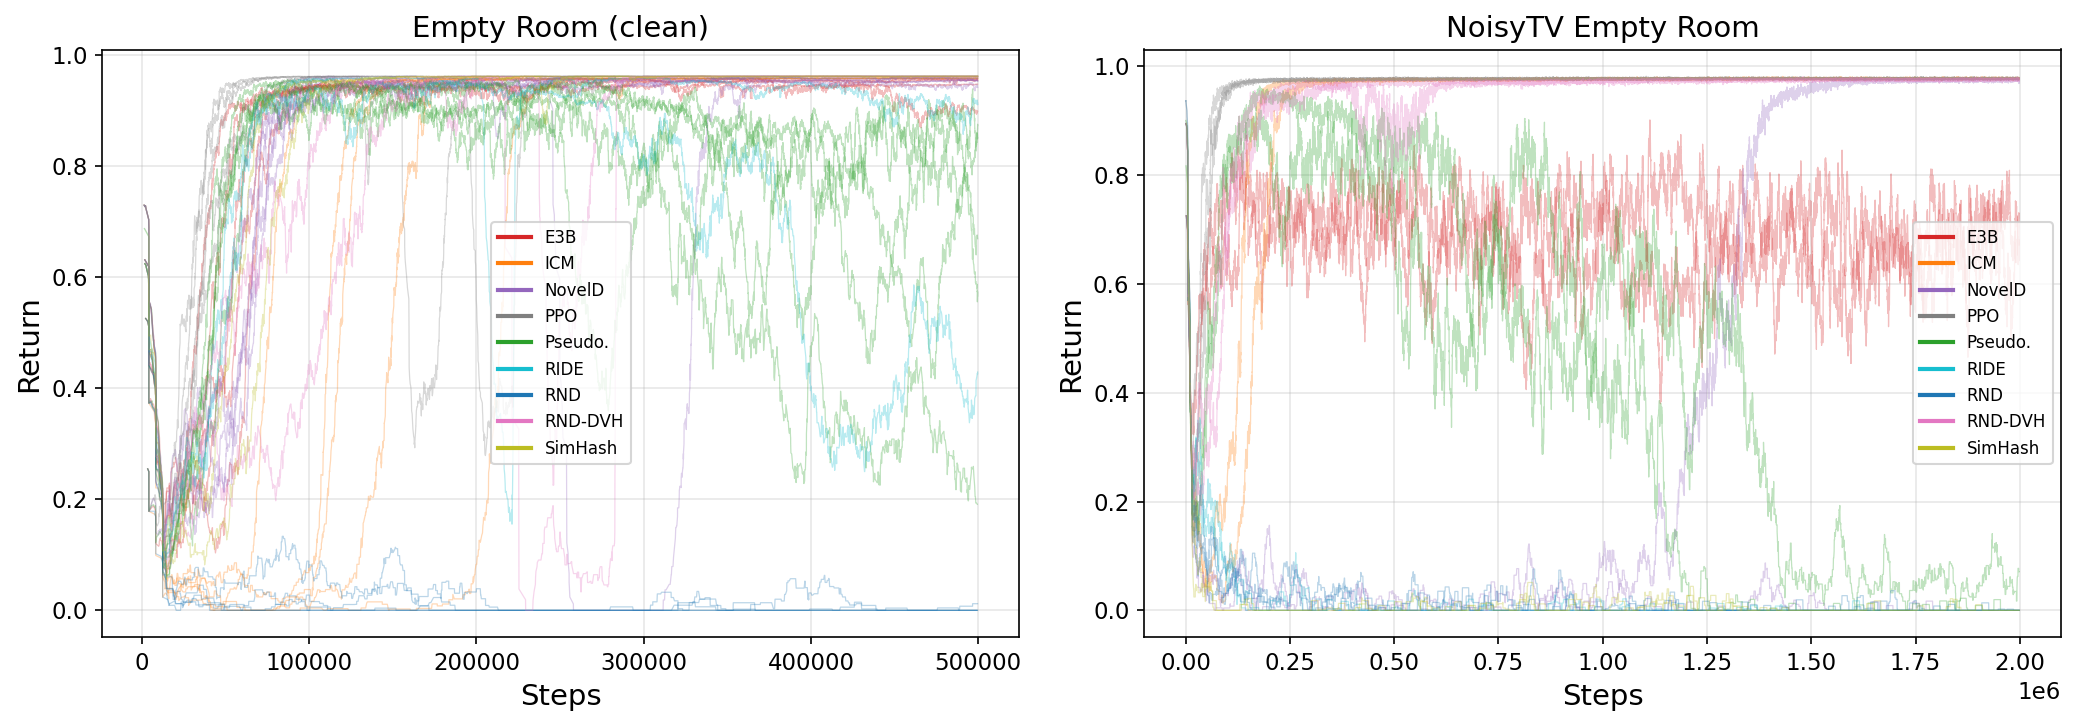

In [21]:
noisy_env = "CustomMiniGrid-NoisyTVEmptyRoom-v0"
normal_env = "MiniGrid-Empty-8x8-v0"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, eid, title in [(ax1, normal_env, "Empty Room (clean)"),
                        (ax2, noisy_env, "NoisyTV Empty Room")]:
    ax.set_title(title); ax.set_xlabel("Steps"); ax.set_ylabel("Return")
    for m in methods:
        if eid not in data[m]: continue
        for seed, d in data[m][eid].items():
            y = smooth(d["returns"], w=50)
            x = d["steps"][:len(y)] if len(d["steps"]) >= len(y) else np.arange(len(y))
            ax.plot(x, y, color=_c(m), alpha=0.3, linewidth=0.6)
        ax.plot([], [], color=_c(m), label=_l(m), linewidth=2)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.savefig(f"{FIGURES_DIR}/noisy_tv_analysis.png"); plt.show()

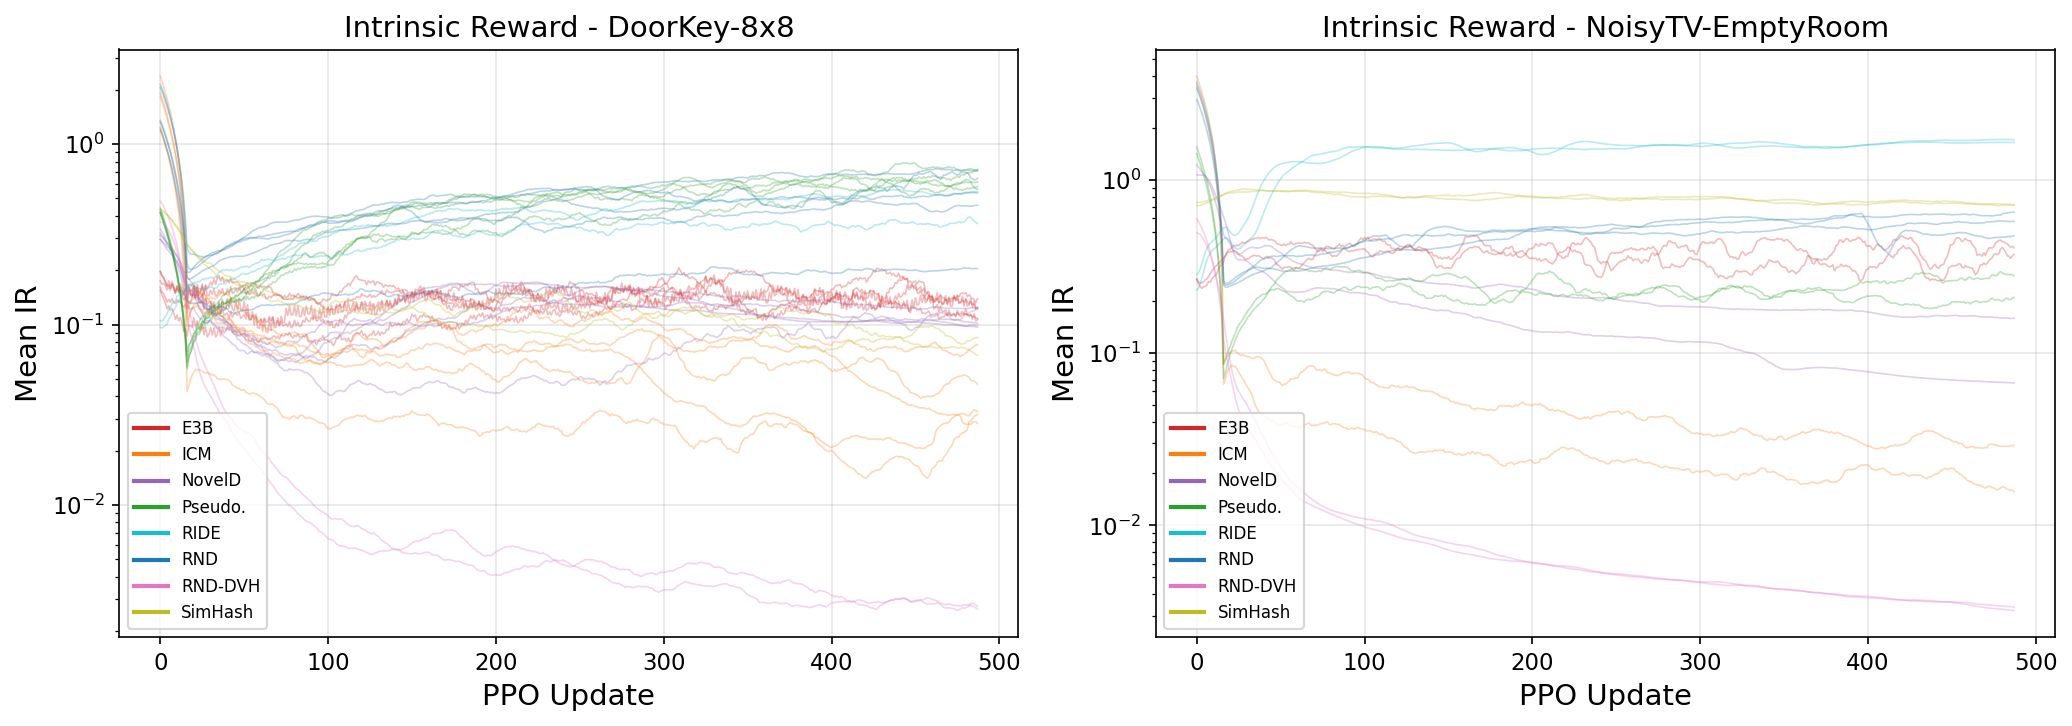

In [22]:
ir_methods = [m for m in methods if m != "ppo_baseline"]
ir_envs = ["MiniGrid-DoorKey-8x8-v0", "CustomMiniGrid-NoisyTVEmptyRoom-v0"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, eid in zip(axes, ir_envs):
    ax.set_title(f"Intrinsic Reward - {_short(eid)}"); ax.set_xlabel("PPO Update")
    ax.set_ylabel("Mean IR"); ax.set_yscale("log")
    for m in ir_methods:
        if eid not in data[m]: continue
        for seed, d in data[m][eid].items():
            ir = d["intrinsic"]
            if len(ir) == 0: continue
            y = smooth(ir, w=max(10, len(ir)//30))
            ax.plot(np.arange(len(y)), y, color=_c(m), alpha=0.3, linewidth=0.8)
        ax.plot([], [], color=_c(m), label=_l(m), linewidth=2)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.savefig(f"{FIGURES_DIR}/intrinsic_reward_dynamics.png"); plt.show()

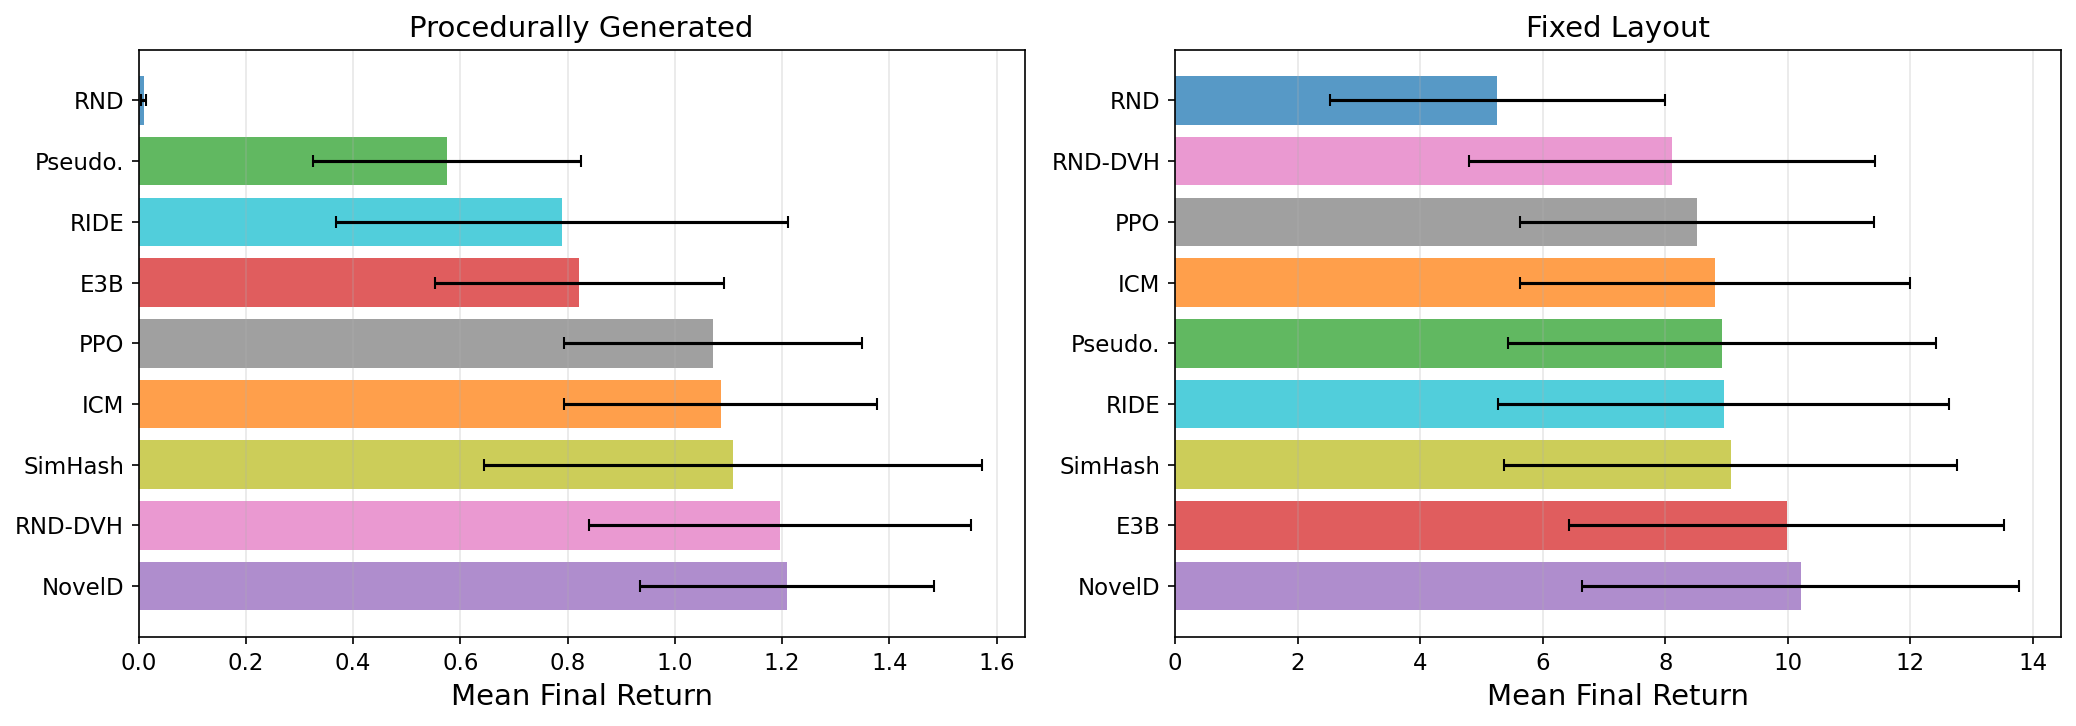

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, group, title in [(ax1, PROCGEN_ENVS, "Procedurally Generated"),
                          (ax2, FIXED_ENVS, "Fixed Layout")]:
    present = [e for e in group if e in env_ids]
    means = {}
    for m in methods:
        vals = [d["summary"].get("final_return_100", 0.0)
                for e in present if e in data[m] for _, d in data[m][e].items()]
        if vals:
            means[m] = (np.mean(vals), np.std(vals) / max(np.sqrt(len(vals)), 1))
    ordered = sorted(means, key=lambda m: means[m][0], reverse=True)
    y = np.arange(len(ordered))
    ax.barh(y, [means[m][0] for m in ordered],
        xerr=[means[m][1] for m in ordered],
        color=[_c(m) for m in ordered], alpha=0.75, capsize=3)
    ax.set_yticks(y); ax.set_yticklabels([_l(m) for m in ordered])
    ax.set_xlabel("Mean Final Return"); ax.set_title(title); ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout(); plt.savefig(f"{FIGURES_DIR}/procgen_vs_fixed.png"); plt.show()

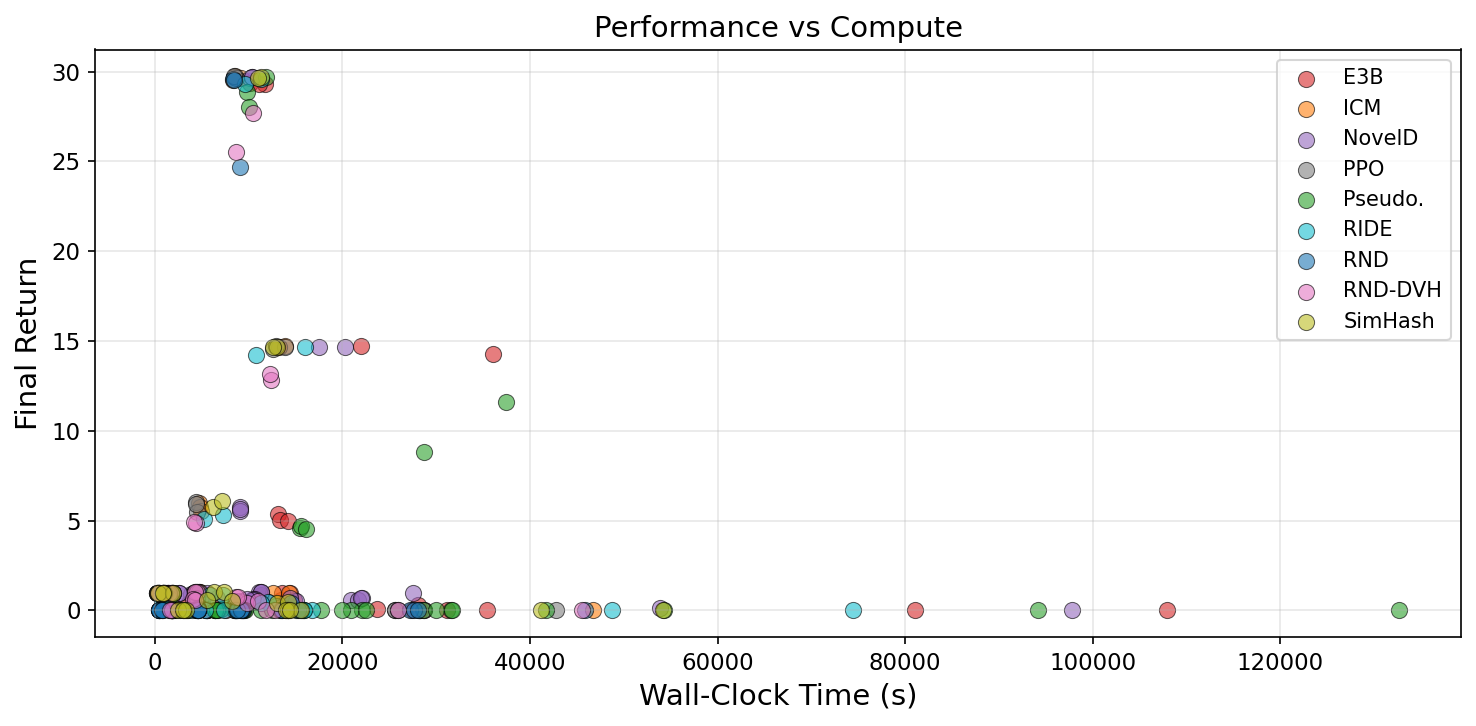

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
for m in methods:
    ts = [d["summary"]["wall_time_s"] for e in env_ids if e in data[m] for _, d in data[m][e].items()]
    rs = [d["summary"]["final_return_100"] for e in env_ids if e in data[m] for _, d in data[m][e].items()]
    if ts:
        ax.scatter(ts, rs, c=_c(m), label=_l(m), s=60, alpha=0.6, edgecolors="black", linewidths=0.5)
ax.set_xlabel("Wall-Clock Time (s)"); ax.set_ylabel("Final Return")
ax.set_title("Performance vs Compute"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(f"{FIGURES_DIR}/efficiency_pareto.png"); plt.show()

In [25]:
print(f"{'Method':<12} {'Environment':<35} {'Mean':>8} {'Std':>8} {'N':>4}")
print("=" * 65)
for m in methods:
    for eid in env_ids:
        if eid not in data[m]: continue
        rets = [data[m][eid][s]["summary"]["final_return_100"] for s in data[m][eid]]
        print(f"{_l(m):<12} {_short(eid):<35} {np.mean(rets):>8.4f} {np.std(rets):>8.4f} {len(rets):>4}")
print("=" * 65)

Method       Environment                             Mean      Std    N
E3B          BranchingCorridors                    0.5099   0.0792    3
E3B          BranchCorr-Fixed                      0.9301   0.0435    3
E3B          DelayedKeySpawn                       0.0000   0.0000    2
E3B          FourRoomsTimed                        5.1335   0.1713    3
E3B          KeyChain                             29.3260   0.0230    3
E3B          NoisyTV-EmptyRoom                     0.6855   0.0132    2
E3B          TreasureIsland                       14.4915   0.2315    2
E3B          DoorKey-8x8                           0.0000   0.0000    5
E3B          Empty-8x8                             0.9417   0.0227    5
E3B          FourRooms                             0.0860   0.1468    5
E3B          KeyCorridor-S6R3                      0.0000   0.0000    1
E3B          LavaGap-S7                            0.4079   0.0289    2
E3B          MultiRoom-N4-S5                       0.0818   0.10

In [ ]:
# Helper for learning curve grids
def plot_lc_grid(envs, titles, figsize, rect, filename, ncols_leg=5):
    nrows = (len(envs) + 2) // 3
    ncols = min(len(envs), 3)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    for idx, (eid, title) in enumerate(zip(envs, titles)):
        ax = axes[idx//ncols][idx%ncols]
        ax.set_title(title, fontsize=9); ax.grid(True, alpha=0.2)
        ax.set_xlabel("Steps", fontsize=7)
        if idx % ncols == 0: ax.set_ylabel("Episode Return", fontsize=8)
        for m in methods:
            if eid not in data[m]: continue
            all_x, all_y = [], []
            for seed, d in data[m][eid].items():
                steps, rets = d["steps"].astype(float), d["returns"].astype(float)
                ys = smooth(rets, aw(len(rets)))
                ax.plot(steps, ys, color=_c(m), alpha=0.2, lw=0.4, rasterized=True)
                all_x.append(steps); all_y.append(ys)
            if all_x:
                xlo, xhi = max(a.min() for a in all_x), min(a.max() for a in all_x)
                cx = np.linspace(xlo, xhi, min(500, min(len(a) for a in all_x)))
                my = np.mean([np.interp(cx, xs, ys) for xs, ys in zip(all_x, all_y)], axis=0)
                ax.plot(cx, smooth(my, aw(len(my))), color=_c(m), alpha=0.9, lw=1.5, label=_l(m), rasterized=True)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(sfmt))
    for idx in range(len(envs), nrows*ncols):
        axes[idx//ncols][idx%ncols].set_visible(False)
    handles = [plt.Line2D([0],[0], color=_c(m), lw=1.5) for m in methods]
    fig.legend(handles, [_l(m) for m in methods], loc="lower center", ncol=ncols_leg, fontsize=6.5, frameon=False)
    fig.tight_layout(rect=rect)
    fig.savefig(f"{FIGURES_DIR}/{filename}", dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.show()
    print(f"Saved {filename}")

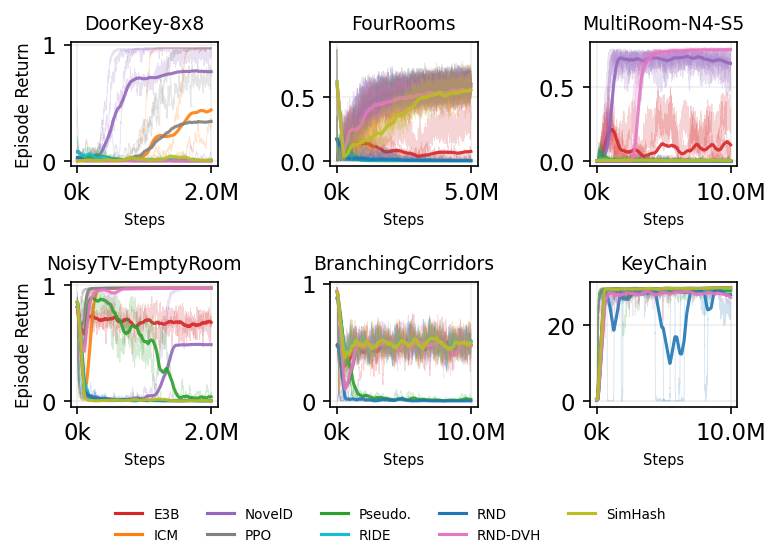

Saved fig_learning_selected.pdf


In [27]:
sel_envs = ["MiniGrid-DoorKey-8x8-v0", "MiniGrid-FourRooms-v0", "MiniGrid-MultiRoom-N4-S5-v0",
            "CustomMiniGrid-NoisyTVEmptyRoom-v0", "CustomMiniGrid-BranchingCorridors-v0", "CustomMiniGrid-KeyChain-v0"]
sel_titles = ["DoorKey-8x8", "FourRooms", "MultiRoom-N4-S5", "NoisyTV-EmptyRoom", "BranchingCorridors", "KeyChain"]
plot_lc_grid(sel_envs, sel_titles, figsize=(5.5, 3.8), rect=[0,0.09,1,0.98], filename="fig_learning_selected.pdf")

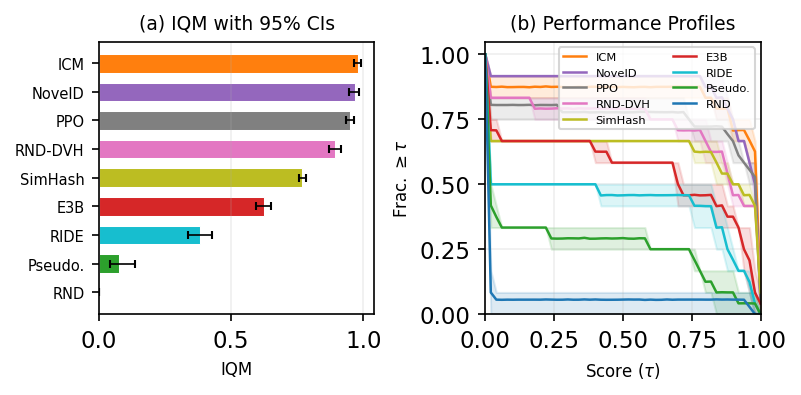

Saved fig_iqm_profiles.pdf


In [ ]:
# IQM + Performance Profiles side by side
label_to_key = {v: k for k, v in LABELS.items()}
sorted_algs = sorted(score_dict, key=lambda m: iqm_scores[m][0], reverse=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5.5, 2.8))

# IQM bars
y = np.arange(len(sorted_algs))
v = [iqm_scores[m][0] for m in sorted_algs]
cl = [float(np.asarray(iqm_cis[m][0]).flat[0]) for m in sorted_algs]
ch = [float(np.asarray(iqm_cis[m][1]).flat[0]) for m in sorted_algs]
errs = np.array([[vi-li, hi-vi] for vi, li, hi in zip(v, cl, ch)]).T
ax1.barh(y, v, xerr=errs, color=[_c(label_to_key.get(m,m)) for m in sorted_algs],
    edgecolor="white", linewidth=0.5, height=0.65, capsize=2, error_kw={"lw": 0.8})
ax1.set_yticks(y); ax1.set_yticklabels(sorted_algs, fontsize=7)
ax1.set_xlabel("IQM", fontsize=8); ax1.set_title("(a) IQM with 95% CIs", fontsize=9)
ax1.invert_yaxis(); ax1.grid(axis="x", alpha=0.2)

# Performance profiles with bootstrap CIs
taus = np.linspace(0, 1, 51)
rng_boot = np.random.RandomState(42)
for m_label in sorted_algs:
    mat = score_dict[m_label]
    means, lows, highs = [], [], []
    for tau in taus:
        fracs = []
        for _ in range(2000):
            idx = rng_boot.choice(mat.shape[0], size=mat.shape[0], replace=True)
            bm = mat[idx]
            valid = ~np.isnan(bm)
            fracs.append(np.sum(bm[valid] >= tau) / valid.sum() if valid.sum() else 0)
        fracs = np.array(fracs)
        means.append(np.mean(fracs)); lows.append(np.percentile(fracs, 2.5)); highs.append(np.percentile(fracs, 97.5))
    c = _c(label_to_key.get(m_label, m_label))
    ax2.plot(taus, means, color=c, lw=1.2, label=m_label)
    ax2.fill_between(taus, lows, highs, color=c, alpha=0.15)

ax2.set_xlabel(r"Score ($\tau$)", fontsize=8); ax2.set_ylabel(r"Frac. $\geq \tau$", fontsize=8)
ax2.set_title("(b) Performance Profiles", fontsize=9)
ax2.legend(fontsize=5.5, ncol=2, loc="upper right"); ax2.grid(True, alpha=0.2)
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1.05)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/fig_iqm_profiles.pdf", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.show(); print("Saved fig_iqm_profiles.pdf")

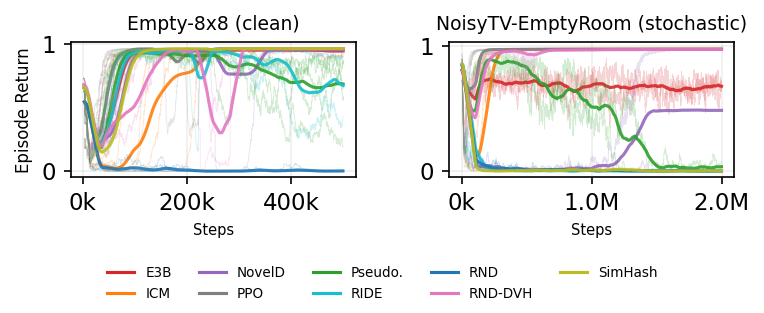

Saved fig_noisy_tv.pdf


In [29]:
ntv_envs = ["MiniGrid-Empty-8x8-v0", "CustomMiniGrid-NoisyTVEmptyRoom-v0"]
ntv_titles = ["Empty-8x8 (clean)", "NoisyTV-EmptyRoom (stochastic)"]
plot_lc_grid(ntv_envs, ntv_titles, figsize=(5.5, 2.2), rect=[0,0.12,1,0.96], filename="fig_noisy_tv.pdf")

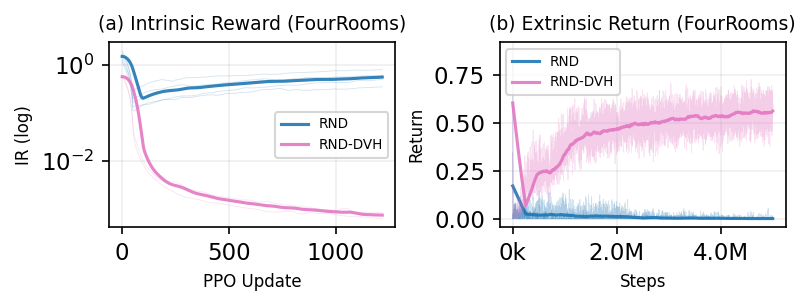

Saved fig_intrinsic_rnd.pdf


In [ ]:
# RND vs RND-DVH mechanism on FourRooms
ir_env = "MiniGrid-FourRooms-v0"
ir_methods = ["rnd", "rnd_raw_dvh"]
ir_labels = {"rnd": "RND", "rnd_raw_dvh": "RND-DVH"}
fig, (axa, axb) = plt.subplots(1, 2, figsize=(5.5, 2.2))

# (a) Intrinsic reward
axa.set_title("(a) Intrinsic Reward (FourRooms)", fontsize=9)
for m in ir_methods:
    if ir_env not in data[m]: continue
    all_x, all_y = [], []
    for seed, d in data[m][ir_env].items():
        ir = d["intrinsic"].astype(float)
        y = smooth(ir, aw(len(ir)))
        axa.plot(np.arange(len(y)), y, color=_c(m), alpha=0.2, lw=0.4, rasterized=True)
        all_x.append(np.arange(len(y))); all_y.append(y)
    if all_x:
        n = min(len(a) for a in all_y)
        my = np.mean([y[:n] for y in all_y], axis=0)
        axa.plot(np.arange(n), smooth(my, aw(n)), color=_c(m), alpha=0.9, lw=1.5, label=ir_labels[m])
axa.set_yscale("log"); axa.set_xlabel("PPO Update", fontsize=8)
axa.set_ylabel("IR (log)", fontsize=8); axa.legend(fontsize=6.5); axa.grid(True, alpha=0.2)

# (b) Extrinsic return
axb.set_title("(b) Extrinsic Return (FourRooms)", fontsize=9)
for m in ir_methods:
    if ir_env not in data[m]: continue
    all_x, all_y = [], []
    for seed, d in data[m][ir_env].items():
        steps, rets = d["steps"].astype(float), d["returns"].astype(float)
        y = smooth(rets, aw(len(rets)))
        axb.plot(steps, y, color=_c(m), alpha=0.2, lw=0.4, rasterized=True)
        all_x.append(steps); all_y.append(y)
    if all_x:
        xlo, xhi = max(a.min() for a in all_x), min(a.max() for a in all_x)
        cx = np.linspace(xlo, xhi, min(500, min(len(a) for a in all_x)))
        my = np.mean([np.interp(cx, xs, ys) for xs, ys in zip(all_x, all_y)], axis=0)
        axb.plot(cx, smooth(my, aw(len(my))), color=_c(m), alpha=0.9, lw=1.5, label=ir_labels[m])
axb.set_xlabel("Steps", fontsize=8); axb.set_ylabel("Return", fontsize=8)
axb.xaxis.set_major_formatter(mticker.FuncFormatter(sfmt))
axb.legend(fontsize=6.5); axb.grid(True, alpha=0.2)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/fig_intrinsic_rnd.pdf", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.show(); print("Saved fig_intrinsic_rnd.pdf")

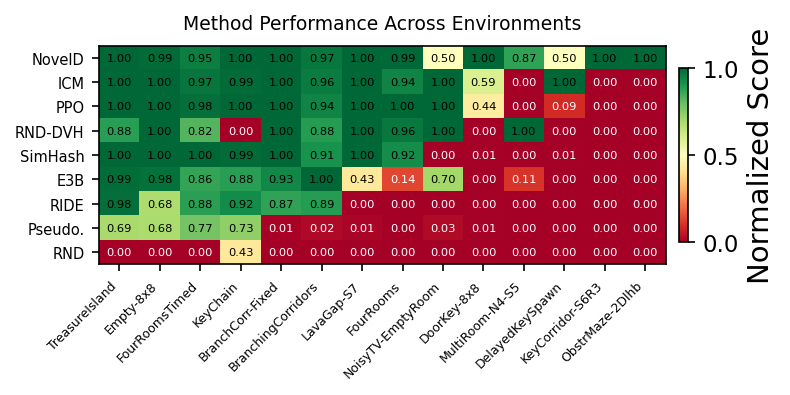

Saved fig_heatmap.pdf


In [ ]:
# method x environment heatmap
all_envs_sorted = sorted(env_ids)
raw_mat, norm_mat = {}, {}
for m in methods:
    for env in all_envs_sorted:
        if env in data[m]:
            raw_mat[(m, env)] = np.mean([data[m][env][s]["summary"]["final_return_100"] for s in data[m][env]])

for env in all_envs_sorted:
    vals = [raw_mat.get((m, env), np.nan) for m in methods]
    vals = [v for v in vals if not np.isnan(v)]
    if not vals: continue
    lo, hi = min(vals), max(vals)
    rng = hi - lo if hi > lo else 1.0
    for m in methods:
        if (m, env) in raw_mat:
            norm_mat[(m, env)] = (raw_mat[(m, env)] - lo) / rng

# Sort methods by aggregate, envs by difficulty
m_agg = {m: np.mean([norm_mat[(m,e)] for e in all_envs_sorted if (m,e) in norm_mat]) for m in methods}
sorted_m = sorted(m_agg, key=lambda m: m_agg[m], reverse=True)
e_diff = {e: np.mean([norm_mat.get((m,e), np.nan) for m in methods
           if not np.isnan(norm_mat.get((m,e), np.nan))]) for e in all_envs_sorted}
sorted_e = sorted(all_envs_sorted, key=lambda e: -e_diff.get(e, 0))

hm = np.full((len(sorted_m), len(sorted_e)), np.nan)
for i, m in enumerate(sorted_m):
    for j, e in enumerate(sorted_e):
        if (m, e) in norm_mat: hm[i, j] = norm_mat[(m, e)]

fig, ax = plt.subplots(figsize=(5.5, 2.8))
cmap = plt.cm.RdYlGn.copy(); cmap.set_bad("#eee")
ax.imshow(hm, cmap=cmap, aspect="auto", vmin=0, vmax=1)
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        v = hm[i,j]
        if np.isnan(v): ax.text(j, i, "--", ha="center", va="center", fontsize=5.5, color="#999")
        else: ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=5.5, color="white" if v < 0.35 else "black")

ax.set_xticks(range(len(sorted_e)))
ax.set_xticklabels([_short(e) for e in sorted_e], rotation=45, ha="right", fontsize=6)
ax.set_yticks(range(len(sorted_m)))
ax.set_yticklabels([_l(m) for m in sorted_m], fontsize=7)
ax.set_title("Method Performance Across Environments", fontsize=9, pad=8)
fig.colorbar(ax.images[0], ax=ax, shrink=0.8, pad=0.02, label="Normalized Score")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/fig_heatmap.pdf", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.show(); print("Saved fig_heatmap.pdf")

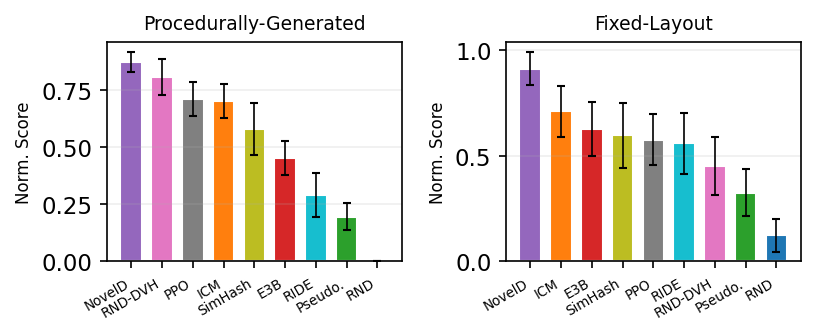

Saved fig_procgen_fixed.pdf


In [ ]:
# procgen vs fixed layout bars
def norm_scores(env_list):
    raw = {}
    for env in env_list:
        vals_all, mv = [], {}
        for m in methods:
            if env in data[m]:
                v = [data[m][env][s]["summary"]["final_return_100"] for s in data[m][env]]
                mv[m] = v; vals_all.extend(v)
        if not vals_all: continue
        lo, hi = min(vals_all), max(vals_all)
        rng = hi - lo if hi > lo else 1.0
        for m in mv:
            raw.setdefault(m, []).extend([(v-lo)/rng for v in mv[m]])
    return {m: (np.mean(raw[m]), np.std(raw[m])/np.sqrt(len(raw[m]))) for m in raw}

fig, (axl, axr) = plt.subplots(1, 2, figsize=(5.5, 2.4))
for ax, envs, title in [(axl, PROCGEN_ENVS, "Procedurally-Generated"),
                         (axr, FIXED_ENVS, "Fixed-Layout")]:
    sc = norm_scores(envs)
    ordered = sorted(sc, key=lambda m: sc[m][0], reverse=True)
    x = np.arange(len(ordered))
    ax.bar(x, [sc[m][0] for m in ordered], yerr=[sc[m][1] for m in ordered],
        color=[_c(m) for m in ordered], edgecolor="white", width=0.7, capsize=2, error_kw={"lw": 0.8})
    ax.set_xticks(x); ax.set_xticklabels([_l(m) for m in ordered], rotation=30, ha="right", fontsize=6.5)
    ax.set_ylabel("Norm. Score", fontsize=8); ax.set_title(title, fontsize=9)
    ax.grid(axis="y", alpha=0.2); ax.set_ylim(bottom=0)

fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/fig_procgen_fixed.pdf", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.show(); print("Saved fig_procgen_fixed.pdf")